# BrushCue Example: Coachella Aesthetic

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/coachella_aesthetic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/coachella-aesthetic

In [ ]:
!pip install brushcue

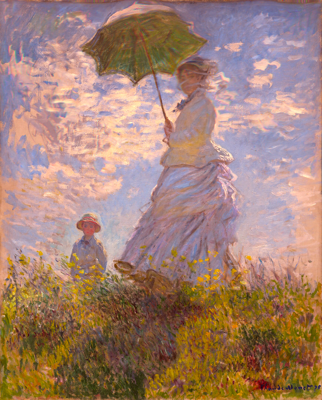

In [1]:
import brushcue
from PIL import Image
import io

input_image_1 = brushcue.composition_monet_women_with_parasol() # insert your own image here
string_constant_2 = brushcue.string_constant("    let size = vec2f(textureDimensions(input_texture));\n    let uv = vec2f(position) / size;\n\n    // Mirage heat distortion — layered sine waves rising from the bottom\n    let heat_influence = pow(1.0 - uv.y, 2.5);\n    let wave1 = sin(uv.x * 18.0 + uv.y * 6.0) * 0.007;\n    let wave2 = sin(uv.x * 31.0 - uv.y * 9.0 + 1.3) * 0.004;\n    let wave3 = sin(uv.x * 9.0 + uv.y * 22.0 + 2.7) * 0.005;\n    let distort = (wave1 + wave2 + wave3) * heat_influence * intensity;\n\n    // Chromatic aberration for trippy fringe\n    let offset = distort * 1.8;\n    let uv_r = uv + vec2f(distort + offset * 0.5, distort * 0.6);\n    let uv_g = uv + vec2f(distort, distort * 0.8);\n    let uv_b = uv + vec2f(distort - offset * 0.4, distort);\n\n    let r = sample(input_texture, clamp(uv_r, vec2f(0.0), vec2f(1.0))).r;\n    let g = sample(input_texture, clamp(uv_g, vec2f(0.0), vec2f(1.0))).g;\n    let b = sample(input_texture, clamp(uv_b, vec2f(0.0), vec2f(1.0))).b;\n    let a = sample(input_texture, clamp(uv_g, vec2f(0.0), vec2f(1.0))).a;\n\n    return vec4f(r, g, b, a);")
empty_helpers_3 = brushcue.string_constant("")
srgb_profile_4 = brushcue.color_profile_s_r_g_b()
bool_constant_5 = brushcue.bool_constant(True)
shader_inputs_6 = brushcue.dictionary_create()
string_constant_7 = brushcue.string_constant("intensity")
float_constant_8 = brushcue.float_constant(1.0)
float_constant_9 = brushcue.float_constant(0.5)
float_constant_10 = brushcue.float_constant(1.0)
float_constant_11 = brushcue.float_constant(0.6000000238418579)
float_constant_12 = brushcue.float_constant(0.15000000596046448)
float_constant_13 = brushcue.float_constant(0.07999999821186066)
float_constant_14 = brushcue.float_constant(0.03999999910593033)
intensity_15 = brushcue.float_passthrough(float_constant_9)
float_multiply_16 = brushcue.float_multiply(float_constant_11, intensity_15)
float_multiply_17 = brushcue.float_multiply(float_constant_12, intensity_15)
float_multiply_18 = brushcue.float_multiply(float_constant_13, intensity_15)
float_multiply_19 = brushcue.float_multiply(float_constant_14, intensity_15)
add_intensity_to_shader_20 = brushcue.float_add_to_dictionary(shader_inputs_6, string_constant_7, intensity_15)
float_add_21 = brushcue.float_add(float_constant_8, float_multiply_16)
float_add_22 = brushcue.float_add(float_constant_10, float_multiply_17)
vector_2_float_from_components_23 = brushcue.vector2f_from_components(float_multiply_18, float_multiply_19)
warm_chroma_shift_24 = brushcue.composition_chroma_offset(input_image_1, vector_2_float_from_components_23)
brighten_for_desert_sun_25 = brushcue.composition_brightness_adjust(warm_chroma_shift_24, float_add_22)
boost_saturation_26 = brushcue.composition_saturation_adjust(brighten_for_desert_sun_25, float_add_21)
mirage_heat_distortion_27 = brushcue.composition_custom_transformer_shader(boost_saturation_26, string_constant_2, empty_helpers_3, srgb_profile_4, srgb_profile_4, add_intensity_to_shader_20, bool_constant_5)

ctx = brushcue.Context()
result = mirage_heat_distortion_27.execute(ctx)
composition = result.as_composition()
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400)) # remove this line for full resolution
img
